## BTSP in a T-maze

* T-maze, largely fixed direction navigation, randomly selecting target arm on each trajectory
* CA3: 40 preset place fields
* CA1: 
  * Hebbian learning + BTSP learning at targeted neurons
  * BTSP learning: long-tailed (pre) Hebbian learning with a high output firing rate considered (occurs in one trajectory only)
  * (1) 1 cell, receives BTSP signal at a reward location

Evaluate resulting CA1 neuron place field properties

In [1]:
import copy
from typing import Any
import warnings

from matplotlib import pyplot as plt
import numpy as np
import ratinabox
from tqdm import tqdm

from predhpc import agent, env, run_manager, plot_util, util, params_util
from predhpc.neurons import learning_neurons, two_comp_neurons, object_neurons

In [2]:
plot_util.stylize_plots_for_notebook()
ratinabox.autosave_plots = False
ratinabox.figure_directory = "figures"

In [3]:
warnings.filterwarnings(
    "ignore", message="invalid value encountered", 
    category=RuntimeWarning
)

## Reload

In [4]:
import importlib
importlib.reload(agent)
importlib.reload(env)
importlib.reload(learning_neurons)
importlib.reload(two_comp_neurons)
importlib.reload(object_neurons)
importlib.reload(run_manager)
importlib.reload(plot_util)
importlib.reload(util)
importlib.reload(params_util);

## T-maze BTSP

100%|███████████████████████████████████████| 8000/8000 [01:32<00:00, 86.23it/s]


Only reached the reward 6 times (target: 8).
Trajectory lengths (14) to date: 17.14 +/- 3.41 sec each
Trajectory lengths (14) to date: 571.43 +/- 113.65 steps each


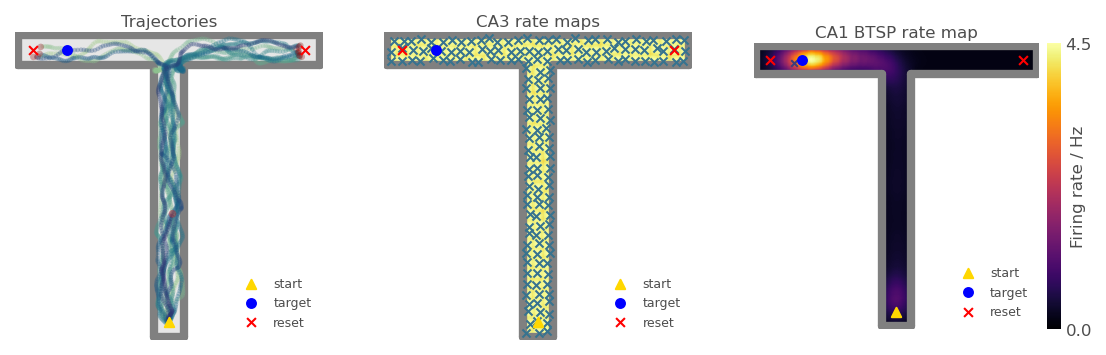

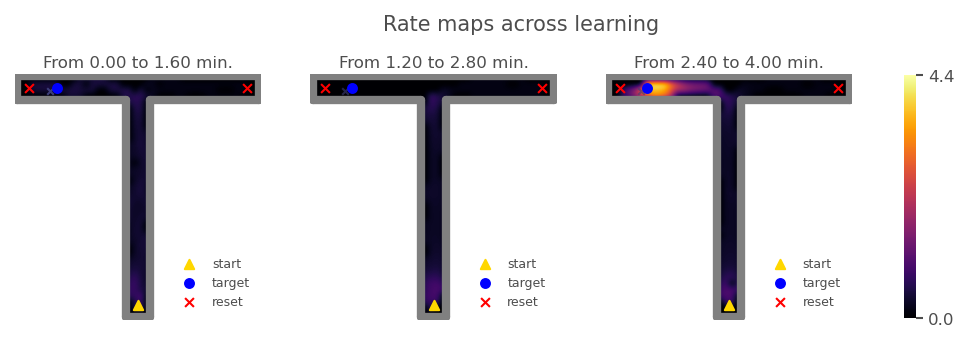

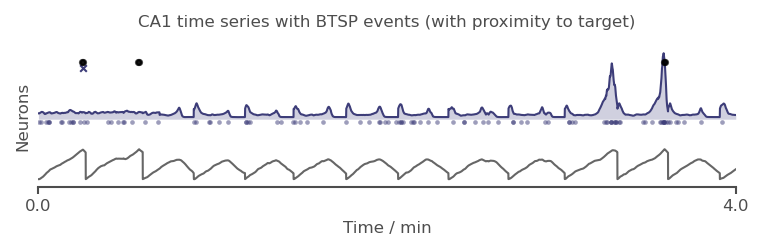

In [5]:
CA3_PC_params = params_util.get_CA3_PC_params(
    environment="tmaze", 
    n=177, # 40, # for one column and one row 
    place_cell_centres="uniform_jitter",
)

Env, Ag, _, CA3_PCs, CA1s = run_manager.learn_T_maze_BTSP(
    CA3_PC_params=CA3_PC_params,
    num_rewards=8, 
    max_num_steps=8000, 
    weight_recording_freq=100, 
    use_Hebbian=False,
    BTSP_after_num_target_reaches=2,
    two_compartment=False
)

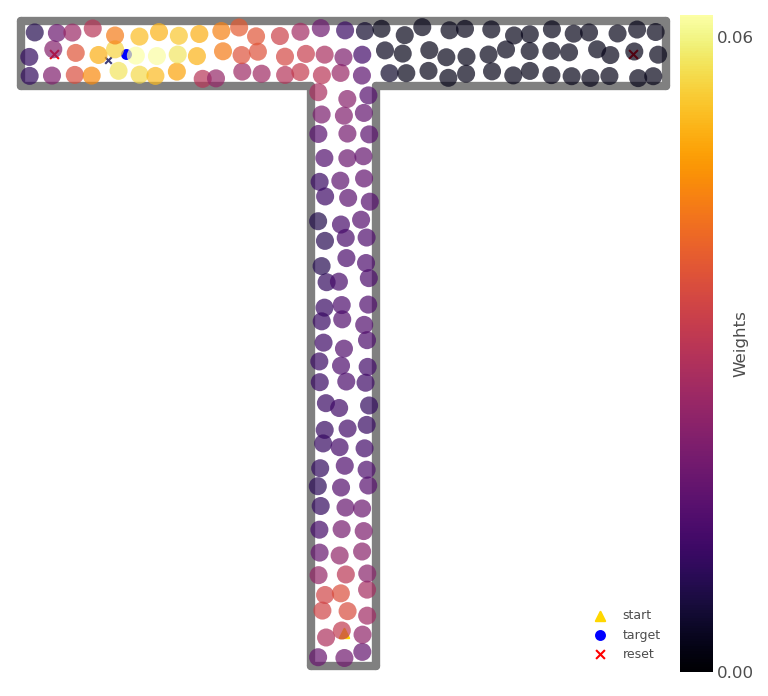

In [6]:
plot_util.plot_2D_input_place_cell_weights(CA1s, plot_BTSP_events=True);

## Distance to target

8


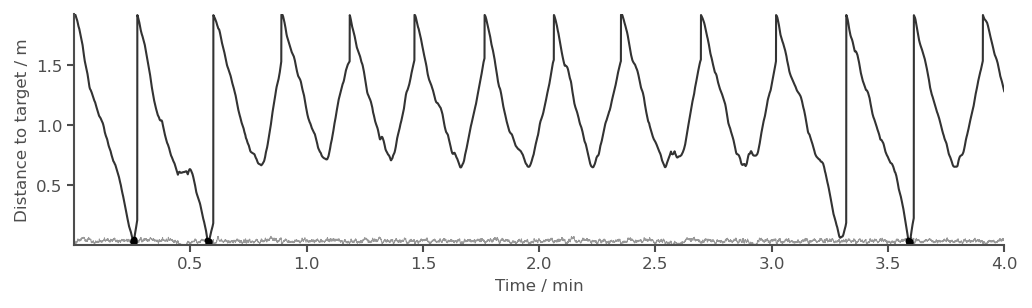

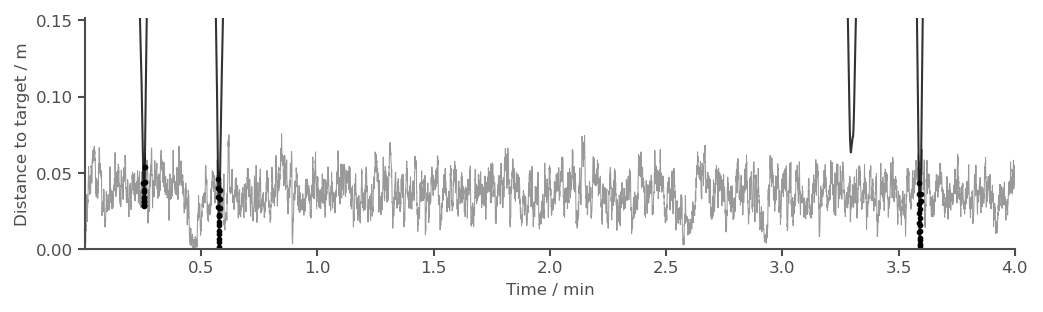

In [7]:
Ag.plot_distance_to(mark_below_tolerance=True)
Ag.plot_distance_to(zoom_prop=2, mark_below_tolerance=True)
print(Ag.target_reached_within_tol_prop_to_speed_dt)

## BTSP filtered inputs

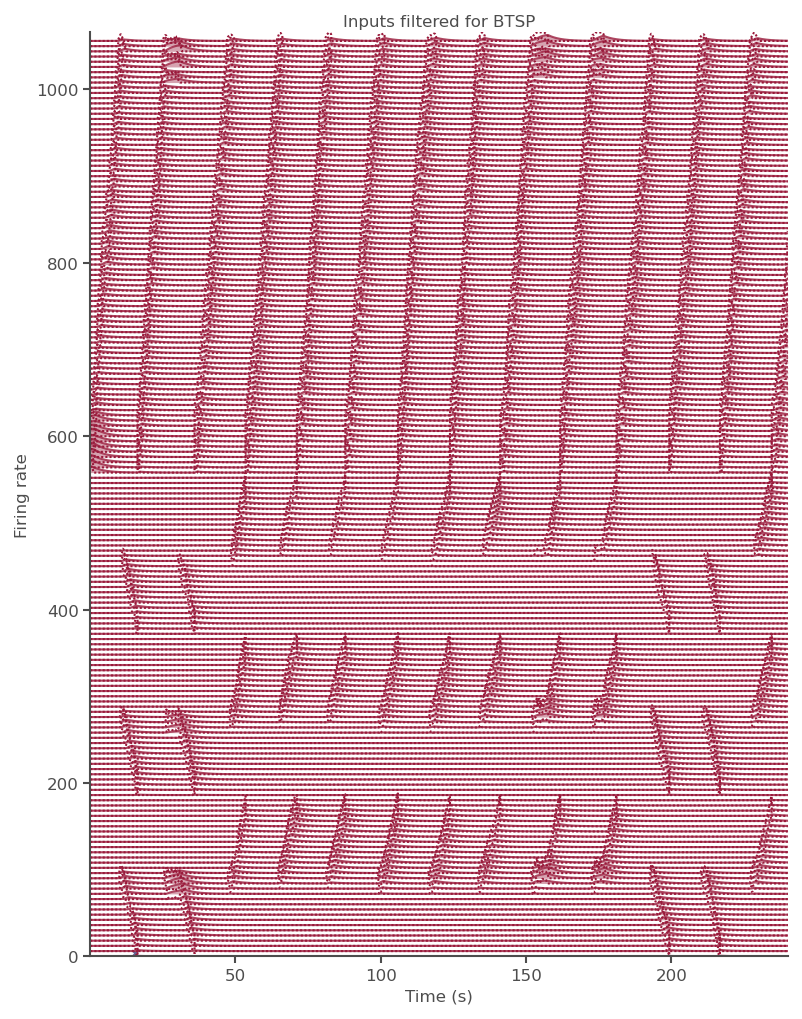

In [8]:
CA1s.plot_filtered_for_BTSP("CA3_PCs");

## BTSP 2-compartment independent

In [9]:
import importlib
importlib.reload(learning_neurons)
importlib.reload(two_comp_neurons)
importlib.reload(object_neurons)
importlib.reload(run_manager)
importlib.reload(plot_util)
importlib.reload(agent)
importlib.reload(env)

from tqdm import tqdm

In [10]:
DT = params_util.DT

env_params = params_util.get_env_params(environment="tmaze")

Ag_params = params_util.get_agent_params(
    environment="tmaze", dt=DT, left_arm_prop=0.8
)

CA3_PC_params = params_util.get_CA3_PC_params(
    environment="tmaze", place_cell_centres="uniform"
)

CA1_params = params_util.get_CA1_params(
    n=1, environment="tmaze", 
    two_compartment=True, BTSP=True,
    soma_BTSP_lr_fact=400,
)

100%|███████████████████████████████████████| 4000/4000 [01:15<00:00, 52.73it/s]


Only reached the reward 6 times (target: 8).
Trajectory lengths (7) to date: 17.14 +/- 1.44 sec each
Trajectory lengths (7) to date: 571.43 +/- 47.84 steps each


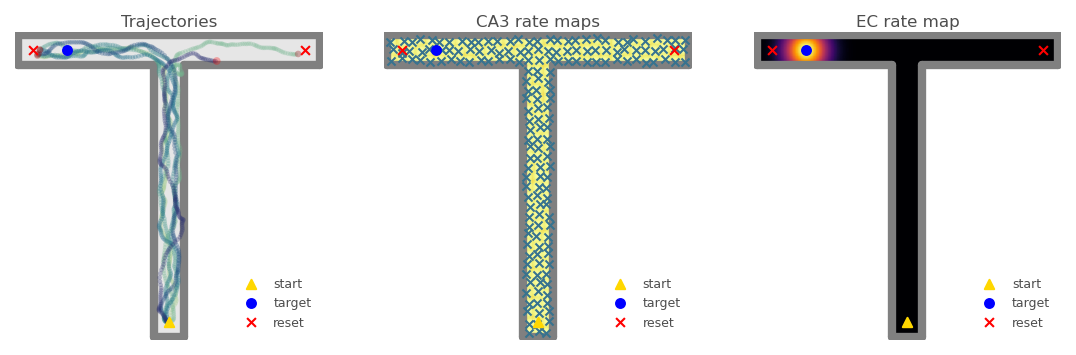

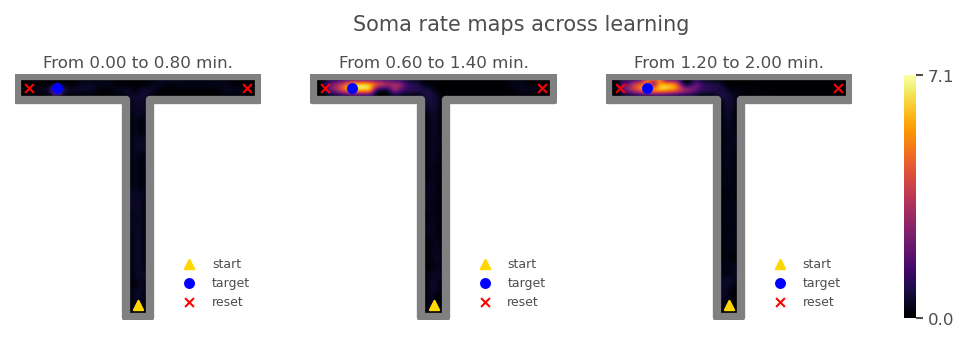

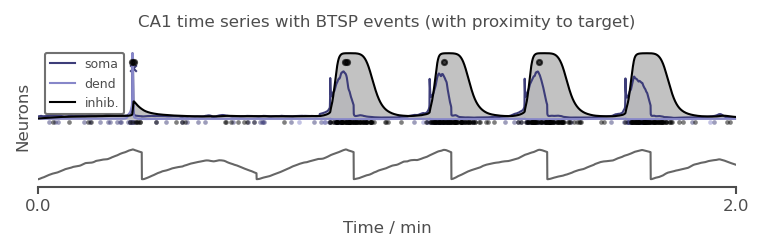

In [11]:
CA3_PC_params = params_util.get_CA3_PC_params(
    environment="tmaze", 
    n=177, # 40, # for one column and one row 
    place_cell_centres="uniform_jitter"
)

Env, Ag, ECs, CA3_PCs, CA1s = run_manager.learn_T_maze_BTSP(
    env_params, 
    Ag_params, 
    CA3_PC_params, 
    CA1_params, 
    num_rewards=8, 
    max_num_steps=4000, 
    weight_recording_freq=100, 
    use_Hebbian=False,
    BTSP_after_num_target_reaches=2, # ignored if 2-compartment
    two_compartment=True
)

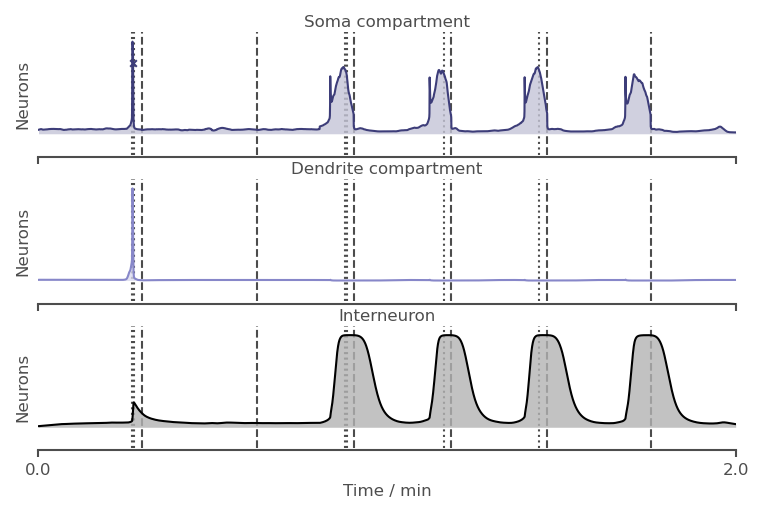

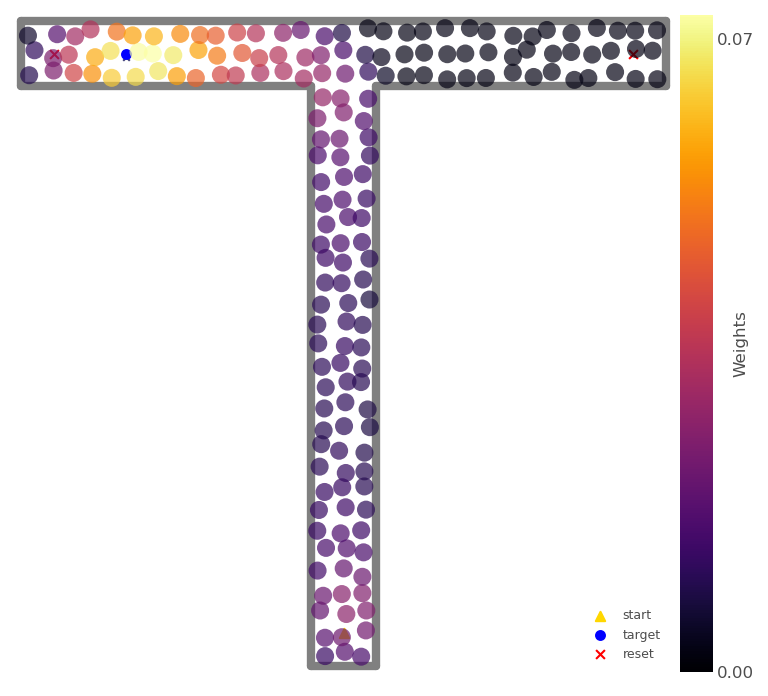

In [12]:
CA1s.plot_rate_timeseries(separate_axes=True)
plot_util.plot_2D_input_place_cell_weights(CA1s.SomaCompartment, plot_BTSP_events=True);

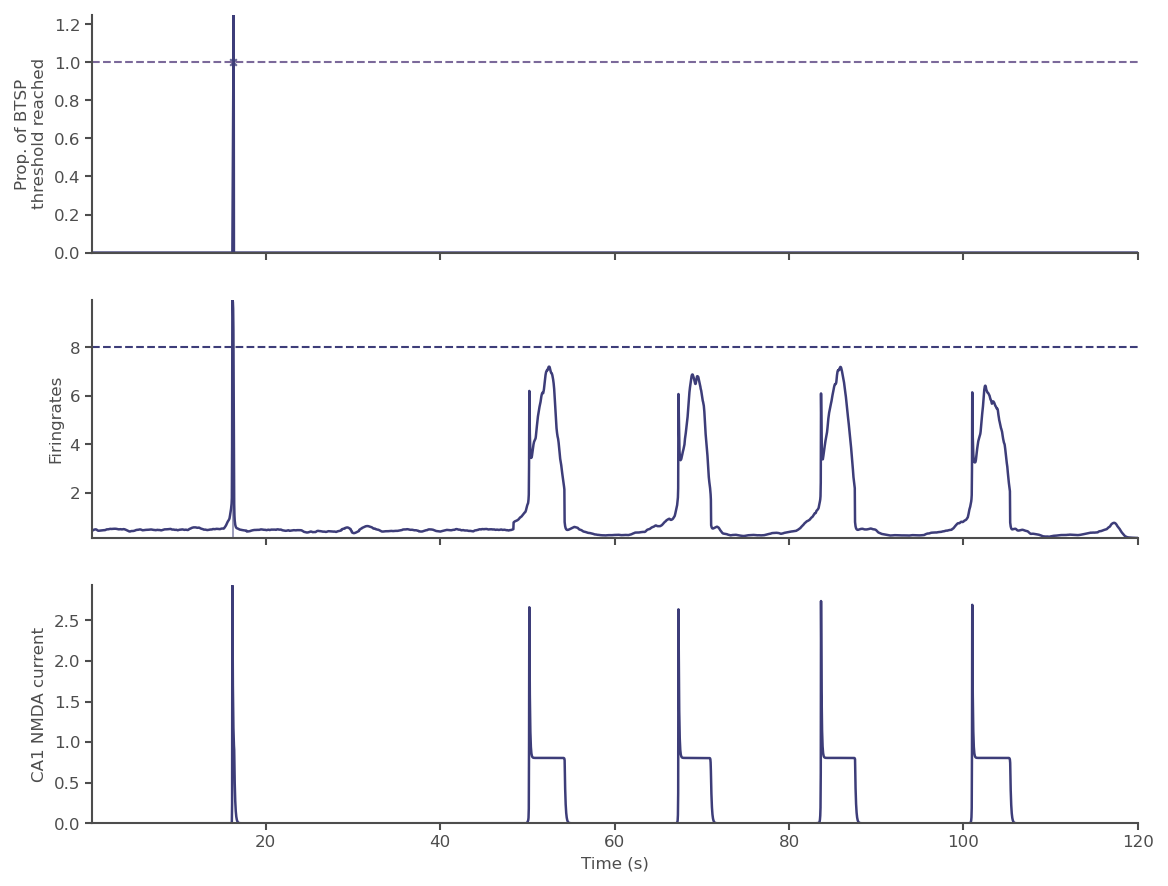

In [13]:
CA1s.SomaCompartment.plot_BTSP_ramp();

BTSP events applied after 1072.00 steps (32.16 sec.) (num steps: 1072).


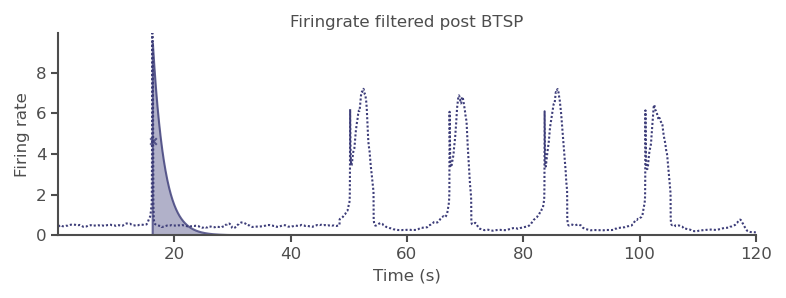

In [14]:
CA1s.SomaCompartment.log_num_steps_to_apply_BTSP()
CA1s.SomaCompartment.plot_filtered_for_BTSP();

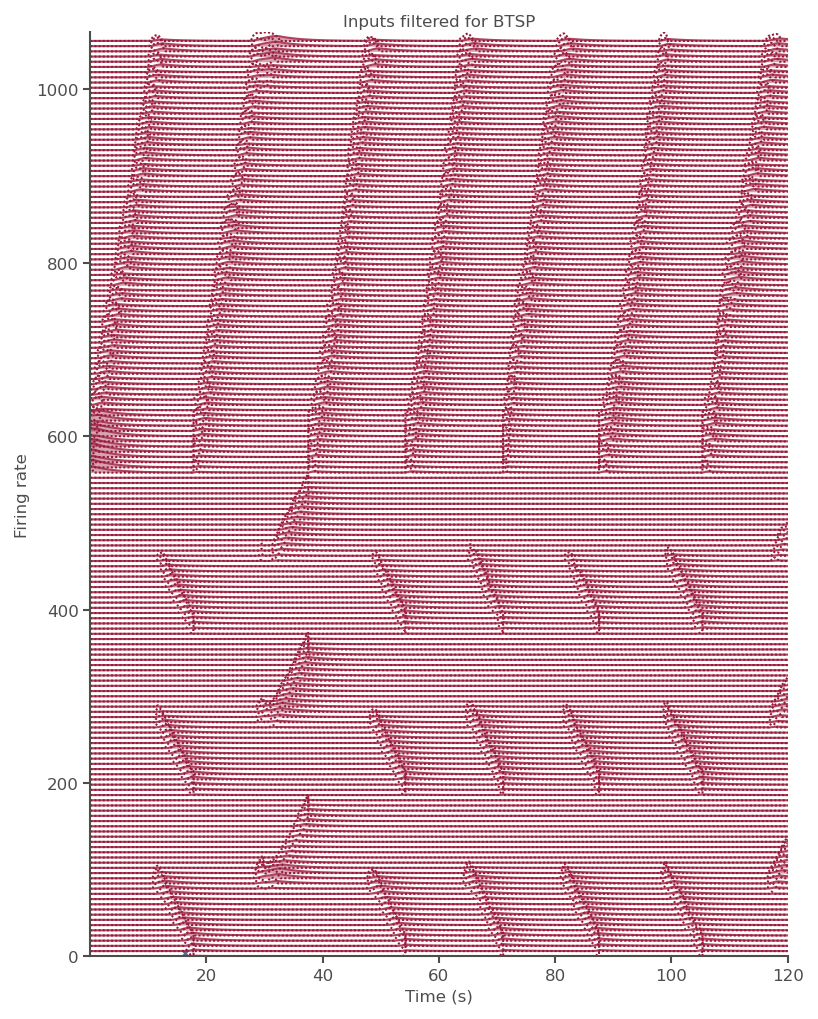

In [15]:
CA1s.SomaCompartment.plot_filtered_for_BTSP("CA3_PCs");

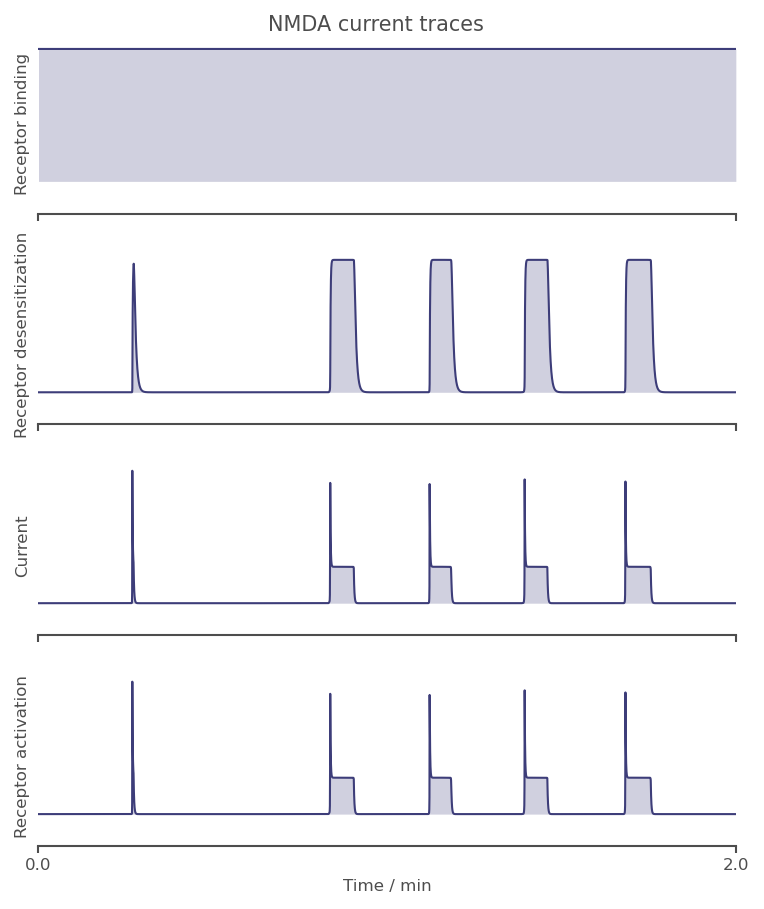

In [16]:
CA1s.SomaCompartment.inputs["NMDACurrent"]["layer"].plot_timeseries(datatypes="all");